# Milestone 6 - Diffusion and Generative AI

This notebook uses product titles, metadata, and cached product images from the frozen `All_Beauty` splits to build a Stable Diffusion product/lifestyle image-generation demo. The notebook is safe to run on a CPU-only machine: the diffusion cell only runs when a supported GPU/runtime and the `diffusers` stack are available or when `RUN_DIFFUSION=1` is set.


## 0. Setup


In [1]:
from __future__ import annotations

import json
import os
import random
import textwrap
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont, ImageOps

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
GENERATED_DIR = REPORTS_DIR / "milestone6_generated_images"

PRODUCT_TRAIN_PATH = PROCESSED_DIR / "product_train.parquet"
PRODUCT_VAL_PATH = PROCESSED_DIR / "product_val.parquet"
PRODUCT_TEST_PATH = PROCESSED_DIR / "product_test.parquet"
META_PATH = PROCESSED_DIR / "all_beauty_meta_sample.parquet"

PROMPT_REPORT_PATH = REPORTS_DIR / "milestone6_diffusion_prompts.csv"
SUMMARY_PATH = REPORTS_DIR / "milestone6_diffusion_summary.json"
GENERATION_MANIFEST_PATH = REPORTS_DIR / "milestone6_generated_image_manifest.csv"

for directory in [REPORTS_DIR, GENERATED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DIFFUSION_MODEL_ID = os.getenv("DIFFUSION_MODEL_ID", "runwayml/stable-diffusion-v1-5")
RUN_DIFFUSION_SETTING = os.getenv("RUN_DIFFUSION", "auto").lower()
NUM_PRODUCTS_TO_DEMO = int(os.getenv("NUM_DIFFUSION_PRODUCTS", "3"))
NUM_INFERENCE_STEPS = int(os.getenv("DIFFUSION_STEPS", "25"))
GUIDANCE_SCALE = float(os.getenv("DIFFUSION_GUIDANCE_SCALE", "7.5"))
IMAGE_SIZE = int(os.getenv("DIFFUSION_IMAGE_SIZE", "512"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Generated image dir: {GENERATED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Diffusion model id: {DIFFUSION_MODEL_ID}")
print(f"RUN_DIFFUSION setting: {RUN_DIFFUSION_SETTING}")


Project root: /Users/nazrinaliyeva/Desktop/smart_e_commerce_assistant
Generated image dir: reports/milestone6_generated_images
Diffusion model id: runwayml/stable-diffusion-v1-5
RUN_DIFFUSION setting: auto


## 1. Load Frozen Product Splits


In [3]:
train_products = pd.read_parquet(PRODUCT_TRAIN_PATH)
val_products = pd.read_parquet(PRODUCT_VAL_PATH)
test_products = pd.read_parquet(PRODUCT_TEST_PATH)

products = pd.concat([train_products, val_products, test_products], ignore_index=True)
products.shape, products["split"].value_counts().to_dict()


((25371, 18), {'train': 17759, 'val': 3806, 'test': 3806})

## 2. Product-Level Leakage Check


In [4]:
split_sets = {name: set(df["product_id"]) for name, df in [("train", train_products), ("val", val_products), ("test", test_products)]}
leakage = {
    "train_val_overlap": len(split_sets["train"] & split_sets["val"]),
    "train_test_overlap": len(split_sets["train"] & split_sets["test"]),
    "val_test_overlap": len(split_sets["val"] & split_sets["test"]),
}
leakage


{'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}

## 3. Add Description and Feature Context


In [5]:
def normalize_list_text(value, max_items=4):
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, list):
        parts = [str(x).strip() for x in value if str(x).strip()]
    elif pd.isna(value):
        parts = []
    else:
        parts = [str(value).strip()]
    return " ".join(parts[:max_items])

if META_PATH.exists():
    meta = pd.read_parquet(META_PATH)[["parent_asin", "features", "description", "details"]].rename(columns={"parent_asin": "product_id"})
    meta["feature_text"] = meta["features"].apply(normalize_list_text)
    meta["description_text"] = meta["description"].apply(normalize_list_text)
    meta["details_text"] = meta["details"].fillna("").astype(str).str.replace(r"[{}\"']", " ", regex=True)
    products = products.merge(meta[["product_id", "feature_text", "description_text", "details_text"]], on="product_id", how="left")
else:
    products["feature_text"] = ""
    products["description_text"] = ""
    products["details_text"] = ""

for col in ["feature_text", "description_text", "details_text"]:
    products[col] = products[col].fillna("").astype(str)

products[["product_id", "product_title", "feature_text", "description_text", "details_text"]].head(3)


,product_id,product_title,feature_text,description_text,details_text
0,B01CUPMQZE,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",,,"Package Dimensions : 7.1 x 5.5 x 3 inches; 2.38 Pounds , UPC : 617390882781"
1,B088FKY3VD,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authentic Eyebrows Waterproof Long Lasting for W...",,,"Brand : Cherioll , Item Form : Powder , Finish Type : Natural , Product Benefits : Long Lasting , Skin Type : All , Package ..."
2,B07CV988JX,TOODOO 8 Sets Mermaid Face Gems Glitter Sticker Rhinestone Bindis Crystal Face Tattoo Forehead Decorations for Women Favors (Delicate Pa...,"Wide usage: you can put these gems on your face, forehead, eyebrows, cheeks, around your eyes, arms, hands or any other body parts, thes...","Feature: Wide usage: You can put these gems on your face, forehead, eyebrows, cheeks, around your eyes, arms, hands or any other body p...","Brand : TOODOO , Water Resistance Level : Water Resistant , Pattern : Delicate Pattern , Number of Pieces : 8 , Age Range (Des..."


## 4. Select Demo Products With Cached Images


In [6]:
def local_image_exists(path_value):
    if not isinstance(path_value, str) or not path_value.strip():
        return False
    path = Path(path_value)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.exists()

candidate_products = products[
    products["product_title"].fillna("").str.len().between(15, 140)
    & products["cached_image_path"].apply(local_image_exists)
].copy()

# Prefer products with some descriptive metadata and enough rating/review signal.
candidate_products["context_chars"] = (
    candidate_products["feature_text"].str.len()
    + candidate_products["description_text"].str.len()
    + candidate_products["details_text"].str.len()
)
candidate_products["selection_score"] = (
    candidate_products["context_chars"].clip(0, 500)
    + candidate_products["rating_number"].fillna(0).clip(0, 200)
    + candidate_products["review_count"].fillna(0).clip(0, 50)
)

demo_products = (
    candidate_products.sort_values(["selection_score", "split"], ascending=[False, True])
    .drop_duplicates("product_id")
    .head(NUM_PRODUCTS_TO_DEMO)
    .reset_index(drop=True)
)

display(demo_products[["product_id", "product_title", "store_name", "split", "rating_band", "cached_image_path", "selection_score"]])
print(f"Selected {len(demo_products)} demo products from {len(candidate_products)} image-backed candidates.")


,product_id,product_title,store_name,split,rating_band,cached_image_path,selection_score
0,B0777W6C4X,"tweexy Wearable Nail Polish Holder Ring, Fingernail Painting Tool, Manicure and Pedicure Accessories (Bonbon Pink & Spa Green, 2-Pack)",tweexy,train,high,data/images/all_beauty/B0777W6C4X_af25fdf540.jpg,709
1,B086HRN773,"John Frieda Frizz Ease Beyond Smooth Frizz-Immunity Shampoo with Frizz-Immunity Conditioner, 8.45oz",John Frieda,train,medium,data/images/all_beauty/B086HRN773_524dd42a6f.jpg,703
2,B07RW78DS8,Nylon Headbands for Baby Girls – Craft DIY Hair Bows – Bulk Wholesale Bands - Nylon Headband Interchangeable,Cherubb,train,high,data/images/all_beauty/B07RW78DS8_144422f4dc.jpg,702


Selected 3 demo products from 51 image-backed candidates.


## 5. Prompt Engineering: Baseline vs Enriched Product Prompt


In [7]:
NEGATIVE_PROMPT = (
    "low quality, blurry, distorted product, deformed text, misspelled label, watermark, logo artifact, "
    "extra hands, cluttered background, unrealistic packaging, duplicate object"
)

def compact_text(text, max_chars=260):
    text = " ".join(str(text).split())
    return text[:max_chars].rsplit(" ", 1)[0] if len(text) > max_chars else text


def build_prompt(row, style="lifestyle"):
    title = compact_text(row.get("product_title", "beauty product"), 120)
    context = compact_text(" ".join([
        row.get("feature_text", ""),
        row.get("description_text", ""),
        row.get("details_text", ""),
    ]), 260)
    store = compact_text(row.get("store_name", ""), 40)
    category = compact_text(row.get("main_category_clean", "All Beauty"), 40)
    if style == "baseline":
        return f"Product photo of {title}"
    if style == "studio":
        return (
            f"Clean commercial studio product photography of {title}. "
            f"Category: {category}. Brand/store: {store}. {context}. "
            "White seamless background, softbox lighting, realistic materials, sharp focus, premium ecommerce listing image."
        )
    return (
        f"Realistic lifestyle advertising image for {title}. "
        f"Category: {category}. Brand/store: {store}. {context}. "
        "Placed naturally on a clean bathroom vanity with soft morning light, premium beauty ecommerce aesthetic, "
        "photorealistic, detailed product, shallow depth of field, no readable text."
    )

prompt_rows = []
for _, row in demo_products.iterrows():
    prompt_rows.append({
        "product_id": row["product_id"],
        "product_title": row["product_title"],
        "split": row["split"],
        "baseline_prompt": build_prompt(row, "baseline"),
        "studio_prompt": build_prompt(row, "studio"),
        "lifestyle_prompt": build_prompt(row, "lifestyle"),
        "negative_prompt": NEGATIVE_PROMPT,
        "source_image_path": row["cached_image_path"],
    })

prompts_df = pd.DataFrame(prompt_rows)
prompts_df.to_csv(PROMPT_REPORT_PATH, index=False)
display(prompts_df[["product_id", "baseline_prompt", "lifestyle_prompt"]])
print(f"Saved prompts to: {PROMPT_REPORT_PATH.relative_to(PROJECT_ROOT)}")


,product_id,baseline_prompt,lifestyle_prompt
0,B0777W6C4X,"Product photo of tweexy Wearable Nail Polish Holder Ring, Fingernail Painting Tool, Manicure and Pedicure Accessories (Bonbon Pink & Spa","Realistic lifestyle advertising image for tweexy Wearable Nail Polish Holder Ring, Fingernail Painting Tool, Manicure and Pedicure Acces..."
1,B086HRN773,"Product photo of John Frieda Frizz Ease Beyond Smooth Frizz-Immunity Shampoo with Frizz-Immunity Conditioner, 8.45oz","Realistic lifestyle advertising image for John Frieda Frizz Ease Beyond Smooth Frizz-Immunity Shampoo with Frizz-Immunity Conditioner, 8..."
2,B07RW78DS8,Product photo of Nylon Headbands for Baby Girls – Craft DIY Hair Bows – Bulk Wholesale Bands - Nylon Headband Interchangeable,Realistic lifestyle advertising image for Nylon Headbands for Baby Girls – Craft DIY Hair Bows – Bulk Wholesale Bands - Nylon Headband I...


Saved prompts to: reports/milestone6_diffusion_prompts.csv


## 6. Baseline Prompt Quality Check

Diffusion is generative rather than predictive, so the useful baseline here is not a classifier baseline; it is a raw title-only prompt. The enriched prompt adds category, store, product details, photographic style, and a negative prompt to reduce common generation failures.


In [8]:
def prompt_quality_features(prompt):
    lower = prompt.lower()
    return {
        "chars": len(prompt),
        "mentions_lighting": int(any(word in lower for word in ["light", "lighting", "softbox"])),
        "mentions_setting": int(any(word in lower for word in ["bathroom", "vanity", "background", "studio"])),
        "mentions_realism": int(any(word in lower for word in ["realistic", "photorealistic", "commercial"])),
        "discourages_text": int("no readable text" in lower),
    }

quality_rows = []
for _, row in prompts_df.iterrows():
    for prompt_type in ["baseline_prompt", "studio_prompt", "lifestyle_prompt"]:
        quality_rows.append({
            "product_id": row["product_id"],
            "prompt_type": prompt_type,
            **prompt_quality_features(row[prompt_type]),
        })

prompt_quality = pd.DataFrame(quality_rows)
prompt_quality["heuristic_score"] = prompt_quality[["mentions_lighting", "mentions_setting", "mentions_realism", "discourages_text"]].sum(axis=1)
display(prompt_quality)


,product_id,prompt_type,chars,mentions_lighting,mentions_setting,mentions_realism,discourages_text,heuristic_score
0,B0777W6C4X,baseline_prompt,136,0,0,0,0,0
1,B0777W6C4X,studio_prompt,583,1,1,1,0,3
2,B0777W6C4X,lifestyle_prompt,647,1,1,1,1,4
3,B086HRN773,baseline_prompt,116,0,0,0,0,0
4,B086HRN773,studio_prompt,568,1,1,1,0,3
5,B086HRN773,lifestyle_prompt,632,1,1,1,1,4
6,B07RW78DS8,baseline_prompt,125,0,0,0,0,0
7,B07RW78DS8,studio_prompt,569,1,1,1,0,3
8,B07RW78DS8,lifestyle_prompt,633,1,1,1,1,4


## 7. Load Stable Diffusion Pipeline

Set `RUN_DIFFUSION=1` before starting Jupyter to force generation. With `RUN_DIFFUSION=auto`, the notebook runs generation only when `diffusers`, `torch`, and a CUDA GPU are available. This avoids accidental multi-hour CPU inference on a local laptop.


In [9]:
def decide_run_diffusion():
    try:
        import torch
        has_cuda = torch.cuda.is_available()
        has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    except Exception:
        has_cuda = False
        has_mps = False
    if RUN_DIFFUSION_SETTING in {"1", "true", "yes"}:
        return True
    if RUN_DIFFUSION_SETTING in {"0", "false", "no"}:
        return False
    return has_cuda  # auto: run on CUDA only unless explicitly forced.

RUN_DIFFUSION = decide_run_diffusion()
PIPELINE_STATUS = {"requested": RUN_DIFFUSION, "loaded": False, "reason": "not requested"}
pipe = None

if RUN_DIFFUSION:
    try:
        import torch
        from diffusers import StableDiffusionPipeline

        if torch.cuda.is_available():
            torch_dtype = torch.float16
            device = "cuda"
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            torch_dtype = torch.float32
            device = "mps"
        else:
            torch_dtype = torch.float32
            device = "cpu"

        pipe = StableDiffusionPipeline.from_pretrained(
            DIFFUSION_MODEL_ID,
            torch_dtype=torch_dtype,
            safety_checker=None,
            requires_safety_checker=False,
        )
        pipe = pipe.to(device)
        if hasattr(pipe, "enable_attention_slicing"):
            pipe.enable_attention_slicing()
        PIPELINE_STATUS = {"requested": True, "loaded": True, "device": device, "model_id": DIFFUSION_MODEL_ID}
    except Exception as exc:
        PIPELINE_STATUS = {"requested": True, "loaded": False, "reason": repr(exc)}

PIPELINE_STATUS


{'requested': False, 'loaded': False, 'reason': 'not requested'}

## 8. Generate Product/Lifestyle Images


In [10]:
def safe_filename(text):
    keep = [ch.lower() if ch.isalnum() else "_" for ch in str(text)]
    return "".join(keep).strip("_")[:80]

manifest_rows = []
start_time = time.time()

if PIPELINE_STATUS.get("loaded") and pipe is not None:
    import torch
    generator_device = PIPELINE_STATUS.get("device", "cpu")
    for idx, row in prompts_df.iterrows():
        generator = torch.Generator(device=generator_device).manual_seed(SEED + idx)
        output = pipe(
            prompt=row["lifestyle_prompt"],
            negative_prompt=row["negative_prompt"],
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            width=IMAGE_SIZE,
            height=IMAGE_SIZE,
            generator=generator,
        )
        image = output.images[0]
        out_path = GENERATED_DIR / f"m6_{row['product_id']}_{safe_filename(row['product_title'])}.png"
        image.save(out_path)
        manifest_rows.append({
            "product_id": row["product_id"],
            "product_title": row["product_title"],
            "generated_image_path": str(out_path.relative_to(PROJECT_ROOT)),
            "source_image_path": row["source_image_path"],
            "prompt": row["lifestyle_prompt"],
            "negative_prompt": row["negative_prompt"],
            "model_id": DIFFUSION_MODEL_ID,
            "num_inference_steps": NUM_INFERENCE_STEPS,
            "guidance_scale": GUIDANCE_SCALE,
            "status": "generated",
        })
else:
    print("Stable Diffusion generation skipped.")
    print("Reason:", PIPELINE_STATUS.get("reason", "RUN_DIFFUSION was not enabled or no CUDA GPU was detected."))

manifest_columns = [
    "product_id", "product_title", "generated_image_path", "source_image_path", "prompt", "negative_prompt",
    "model_id", "num_inference_steps", "guidance_scale", "status",
]
manifest_df = pd.DataFrame(manifest_rows, columns=manifest_columns)
manifest_df.to_csv(GENERATION_MANIFEST_PATH, index=False)
print(f"Generated images: {len(manifest_df)}")
print(f"Elapsed seconds: {time.time() - start_time:.1f}")
print(f"Saved manifest to: {GENERATION_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")


Stable Diffusion generation skipped.
Reason: not requested
Generated images: 0
Elapsed seconds: 0.0
Saved manifest to: reports/milestone6_generated_image_manifest.csv


## 9. Demo Gallery


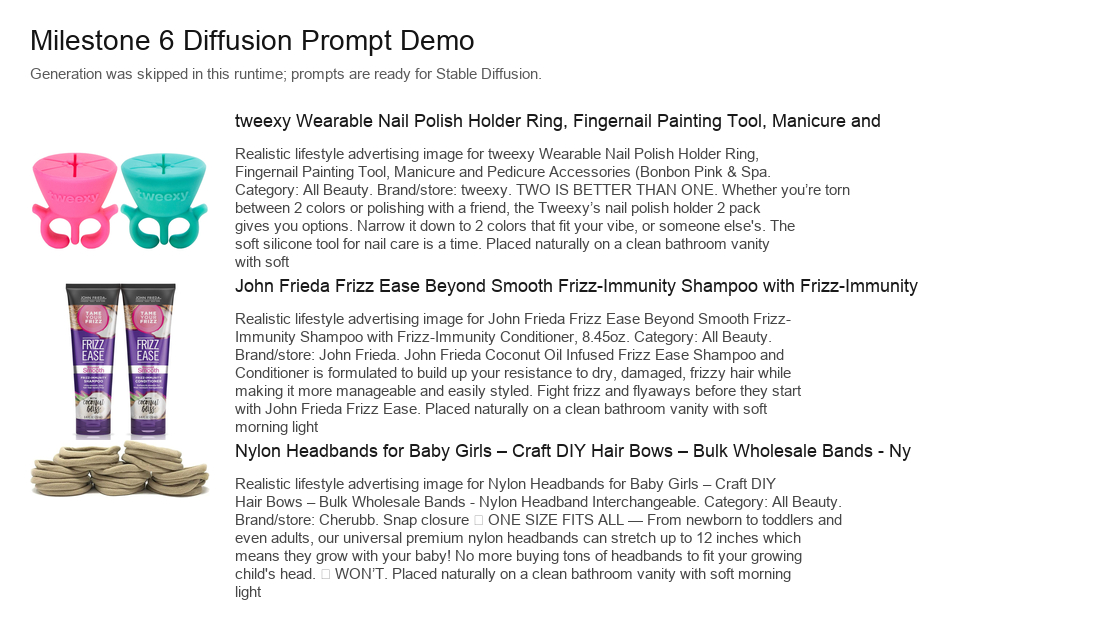

Saved prompt demo card to: reports/milestone6_generated_images/m6_prompt_demo_card.png


In [11]:
def resolve_path(path_value):
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def make_prompt_card(prompts, out_path):
    width, height = 1100, 620
    card = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(card)
    try:
        font_title = ImageFont.truetype("Arial.ttf", 28)
        font_body = ImageFont.truetype("Arial.ttf", 18)
        font_small = ImageFont.truetype("Arial.ttf", 15)
    except Exception:
        font_title = font_body = font_small = ImageFont.load_default()

    draw.text((30, 24), "Milestone 6 Diffusion Prompt Demo", fill=(20, 20, 20), font=font_title)
    draw.text((30, 65), "Generation was skipped in this runtime; prompts are ready for Stable Diffusion.", fill=(90, 90, 90), font=font_small)

    x = 30
    y = 110
    for _, row in prompts.iterrows():
        src = resolve_path(row["source_image_path"])
        if src.exists():
            image = Image.open(src).convert("RGB")
            image = ImageOps.contain(image, (180, 180), Image.Resampling.LANCZOS)
            card.paste(image, (x, y))
        draw.text((x + 205, y), row["product_title"][:80], fill=(25, 25, 25), font=font_body)
        wrapped = textwrap.fill(row["lifestyle_prompt"], width=88)
        draw.multiline_text((x + 205, y + 35), wrapped[:520], fill=(70, 70, 70), font=font_small, spacing=4)
        y += 165
    card.save(out_path)
    return out_path

if not manifest_df.empty:
    n = len(manifest_df)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = np.array([axes])
    for ax_row, (_, row) in zip(axes, manifest_df.iterrows()):
        src_path = resolve_path(row["source_image_path"])
        gen_path = resolve_path(row["generated_image_path"])
        ax_row[0].imshow(Image.open(src_path).convert("RGB"))
        ax_row[0].set_title("Source product image")
        ax_row[0].axis("off")
        ax_row[1].imshow(Image.open(gen_path).convert("RGB"))
        ax_row[1].set_title("Generated lifestyle image")
        ax_row[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    prompt_card_path = GENERATED_DIR / "m6_prompt_demo_card.png"
    make_prompt_card(prompts_df, prompt_card_path)
    display(Image.open(prompt_card_path))
    print(f"Saved prompt demo card to: {prompt_card_path.relative_to(PROJECT_ROOT)}")


## 10. Quality Reflection and Failure Modes


In [12]:
reflection = []
if not manifest_df.empty:
    reflection.append("Stable Diffusion produced product-conditioned lifestyle concepts from title and metadata prompts.")
    reflection.append("The strongest use case is ideation for listing hero images, not replacement of the real product photograph.")
    reflection.append("Likely failure modes: inaccurate packaging geometry, invented labels, unreadable text, wrong scale, and beauty products that look generic when metadata is sparse.")
    reflection.append("The negative prompt discourages blur, watermarks, text artifacts, duplicate objects, and unrealistic packaging, but manual review is still required before using images commercially.")
else:
    reflection.append("This runtime skipped Stable Diffusion generation to keep the notebook reproducible without a GPU or downloaded model weights.")
    reflection.append("The prompt demo still shows the complete product-conditioned generation inputs and saves them for a GPU run.")
    reflection.append("Expected failure modes remain: text/logo artifacts, generic beauty packaging, distorted product shape, and lifestyle scenes that ignore the exact product form.")

for item in reflection:
    display(Markdown(f"- {item}"))


- This runtime skipped Stable Diffusion generation to keep the notebook reproducible without a GPU or downloaded model weights.

- The prompt demo still shows the complete product-conditioned generation inputs and saves them for a GPU run.

- Expected failure modes remain: text/logo artifacts, generic beauty packaging, distorted product shape, and lifestyle scenes that ignore the exact product form.

## 11. Stretch Goal Hook: Generated-Image Augmentation Manifest

If generated images exist, this manifest can be joined to the Milestone 2 image training table for an augmentation experiment. The notebook does not retrain the CNN here because Milestone 6 is about generation quality and demo behavior; retraining can reuse the Milestone 2 pipeline with these extra image paths.


In [13]:
augmentation_manifest = manifest_df.copy()
if not augmentation_manifest.empty:
    augmentation_manifest["augmentation_label"] = "generated_lifestyle"
    augmentation_manifest["suggested_split"] = "train_only"
    display(augmentation_manifest[["product_id", "generated_image_path", "augmentation_label", "suggested_split"]])
else:
    display(Markdown("No generated images are available in this runtime. Run with `RUN_DIFFUSION=1` on a GPU to create augmentation candidates."))


No generated images are available in this runtime. Run with `RUN_DIFFUSION=1` on a GPU to create augmentation candidates.

## 12. Save Milestone Summary


In [14]:
summary = {
    "milestone": "Milestone 6 - Diffusion and Generative AI",
    "model_id": DIFFUSION_MODEL_ID,
    "run_diffusion_setting": RUN_DIFFUSION_SETTING,
    "pipeline_status": PIPELINE_STATUS,
    "num_demo_products": int(len(prompts_df)),
    "num_generated_images": int(len(manifest_df)),
    "prompt_report_path": str(PROMPT_REPORT_PATH.relative_to(PROJECT_ROOT)),
    "generated_image_manifest_path": str(GENERATION_MANIFEST_PATH.relative_to(PROJECT_ROOT)),
    "generated_image_dir": str(GENERATED_DIR.relative_to(PROJECT_ROOT)),
    "negative_prompt": NEGATIVE_PROMPT,
    "reflection": reflection,
    "leakage_check": leakage,
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
print(f"Saved summary to: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


{
  "milestone": "Milestone 6 - Diffusion and Generative AI",
  "model_id": "runwayml/stable-diffusion-v1-5",
  "run_diffusion_setting": "auto",
  "pipeline_status": {
    "requested": false,
    "loaded": false,
    "reason": "not requested"
  },
  "num_demo_products": 3,
  "num_generated_images": 0,
  "prompt_report_path": "reports/milestone6_diffusion_prompts.csv",
  "generated_image_manifest_path": "reports/milestone6_generated_image_manifest.csv",
  "generated_image_dir": "reports/milestone6_generated_images",
  "negative_prompt": "low quality, blurry, distorted product, deformed text, misspelled label, watermark, logo artifact, extra hands, cluttered background, unrealistic packaging, duplicate object",
  "reflection": [
    "This runtime skipped Stable Diffusion generation to keep the notebook reproducible without a GPU or downloaded model weights.",
    "The prompt demo still shows the complete product-conditioned generation inputs and saves them for a GPU run.",
    "Expected 

## 13. Final Interpretation

Milestone 6 adds a generative component to the Smart Product Intelligence system. The product-conditioned prompts are deliberately conservative: they use only frozen product metadata, avoid live image fetching, and preserve the product-level split discipline from earlier milestones. In a GPU runtime, the same notebook produces generated lifestyle images and a manifest that can be reviewed manually or used as train-only augmentation candidates for the vision milestone.
